In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class WaypointRacingEnv(gym.Env):
    """Advanced 2D Waypoint-Based Racing Track Environment"""
    metadata = {"render_modes": ["ansi"]}

    def __init__(self):
        super(WaypointRacingEnv, self).__init__()

        # 5 Discrete Actions: 0: Coast, 1: Left, 2: Right, 3: Accelerate, 4: Brake
        self.action_space = spaces.Discrete(5)

        # Observation Space: 5 Lidar rays + 1 velocity = 6 inputs
        self.observation_space = spaces.Box(
            low=0.0, high=30.0, shape=(6,), dtype=np.float32
        )

        # Define Track Centerline Waypoints (X, Y)
        # This creates a track that goes straight up, bends right, then bends left
        self.waypoints = np.array([
            [0.0, 0.0],
            [0.0, 40.0],    # Straight up
            [20.0, 60.0],   # Bend right-up
            [50.0, 60.0],   # Straight right
            [70.0, 80.0],   # Bend up-right
            [70.0, 120.0]   # Straight up to finish
        ], dtype=np.float32)

        self.TRACK_WIDTH = 12.0
        self.HALF_WIDTH = self.TRACK_WIDTH / 2.0  # 6.0 meters boundaries
        self.DT = 0.1
        self.MAX_SPEED = 10.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Spawn at the first waypoint facing straight up (pi/2 radians)
        self.x = 0.0
        self.y = 0.0
        self.theta = np.pi / 2.0
        self.v = 0.0
        self.steps_taken = 0

        return self._get_obs(), {}

    def _is_inside_track(self, x, y):
        """Helper to determine if an (X,Y) point is within track boundaries"""
        # Find the shortest distance from the point to any track segment
        min_dist = float('inf')
        for i in range(len(self.waypoints) - 1):
            p1 = self.waypoints[i]
            p2 = self.waypoints[i+1]

            # Math vector projection to find distance from point to line segment
            segment_vec = p2 - p1
            point_vec = np.array([x, y]) - p1
            seg_len_sq = np.sum(segment_vec**2)

            if seg_len_sq == 0:
                dist = np.linalg.norm(point_vec)
            else:
                t = max(0.0, min(1.0, np.dot(point_vec, segment_vec) / seg_len_sq))
                projection = p1 + t * segment_vec
                dist = np.linalg.norm(np.array([x, y]) - projection)

            if dist < min_dist:
                min_dist = dist

        return min_dist <= self.HALF_WIDTH, min_dist

    def _get_obs(self):
        """Simulates 5 Lidar rays projecting forward to check boundaries"""
        ray_angles = [-np.pi/2, -np.pi/4, 0.0, np.pi/4, np.pi/2]
        distances = []

        for angle in ray_angles:
            global_angle = self.theta + angle
            found_wall = False

            # Cast out up to 30 meters to locate track edge
            for d in range(1, 31):
                check_x = self.x + d * np.cos(global_angle)
                check_y = self.y + d * np.sin(global_angle)

                inside, _ = self._is_inside_track(check_x, check_y)
                if not inside:
                    distances.append(float(d))
                    found_wall = True
                    break
            if not found_wall:
                distances.append(30.0)

        distances.append(self.v)
        return np.array(distances, dtype=np.float32)

    def step(self, action):
        self.steps_taken += 1

        # Process actions
        if action == 1:   self.theta += 0.15 # Stronger steering turn rate
        elif action == 2: self.theta -= 0.15
        elif action == 3: self.v = min(self.v + 0.5, self.MAX_SPEED)
        elif action == 4: self.v = max(self.v - 0.5, 0.0)

        # Kinematics Update
        self.x += self.v * np.cos(self.theta) * self.DT
        self.y += self.v * np.sin(self.theta) * self.DT

        # Check track constraints
        inside, distance_from_centerline = self._is_inside_track(self.x, self.y)

        # Terminal checks (crashed or completed the waypoint sequence)
        crashed = not inside
        reached_end = self.y >= 115.0  # Safe finish threshold near last waypoint
        timeout = self.steps_taken >= 400

        terminated = crashed or reached_end
        truncated = timeout

        # Structured reward function
        if crashed:
            reward = -200.0
        elif reached_end:
            reward = 500.0  # Massive success bonus for clean completion
        else:
            # Reward velocity while minimizing tracking offset errors
            reward = float(self.v) - (distance_from_centerline * 2.0)

        return self._get_obs(), reward, terminated, truncated, {}

In [3]:
!pip install gymnasium stable-baselines3 shimmy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.4 MB/s eta 0:00:00


In [4]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Instantiate our new waypoint track environment
bm_env = WaypointRacingEnv()

# 2. Define the training checkpoints
total_steps = 40000
eval_freq = 5000
steps_axis = list(range(eval_freq, total_steps + 1, eval_freq))

# --- TRAIN MODEL 1: Long-Term Planner (Gamma = 0.99) ---
print("--- Training Long-Term Planner (Gamma = 0.99) ---")
model_long = PPO("MlpPolicy", bm_env, verbose=0, learning_rate=0.0005, gamma=0.99)
rewards_long = []

for steps in steps_axis:
    model_long.learn(total_timesteps=eval_freq, reset_num_timesteps=False)
    mean_r, _ = evaluate_policy(model_long, bm_env, n_eval_episodes=3)
    rewards_long.append(mean_r)
    print(f"Steps: {steps} | Mean Evaluation Reward: {mean_r:.2f}")

# --- TRAIN MODEL 2: Short-Term Speedster (Gamma = 0.70) ---
print("\n--- Training Short-Term Speedster (Gamma = 0.70) ---")
model_short = PPO("MlpPolicy", bm_env, verbose=0, learning_rate=0.0005, gamma=0.70)
rewards_short = []

for steps in steps_axis:
    model_short.learn(total_timesteps=eval_freq, reset_num_timesteps=False)
    mean_r, _ = evaluate_policy(model_short, bm_env, n_eval_episodes=3)
    rewards_short.append(mean_r)
    print(f"Steps: {steps} | Mean Evaluation Reward: {mean_r:.2f}")

print("\nBenchmarking complete!")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


--- Training Long-Term Planner (Gamma = 0.99) ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Steps: 5000 | Mean Evaluation Reward: 1758.05
Steps: 10000 | Mean Evaluation Reward: 1747.15
Steps: 15000 | Mean Evaluation Reward: 1747.78
Steps: 20000 | Mean Evaluation Reward: 1722.02
Steps: 25000 | Mean Evaluation Reward: 1692.20
Steps: 30000 | Mean Evaluation Reward: 1894.76
Steps: 35000 | Mean Evaluation Reward: 1866.51
Steps: 40000 | Mean Evaluation Reward: 1923.96

--- Training Short-Term Speedster (Gamma = 0.70) ---
Steps: 5000 | Mean Evaluation Reward: 459.42
Steps: 10000 | Mean Evaluation Reward: 1564.44
Steps: 15000 | Mean Evaluation Reward: 1903.45
Steps: 20000 | Mean Evaluation Reward: 1753.97
Steps: 25000 | Mean Evaluation Reward: 1963.79
Steps: 30000 | Mean Evaluation Reward: 1969.59
Steps: 35000 | Mean Evaluation Reward: 1986.04
Steps: 40000 | Mean Evaluation Reward: 1982.63

Benchmarking complete!


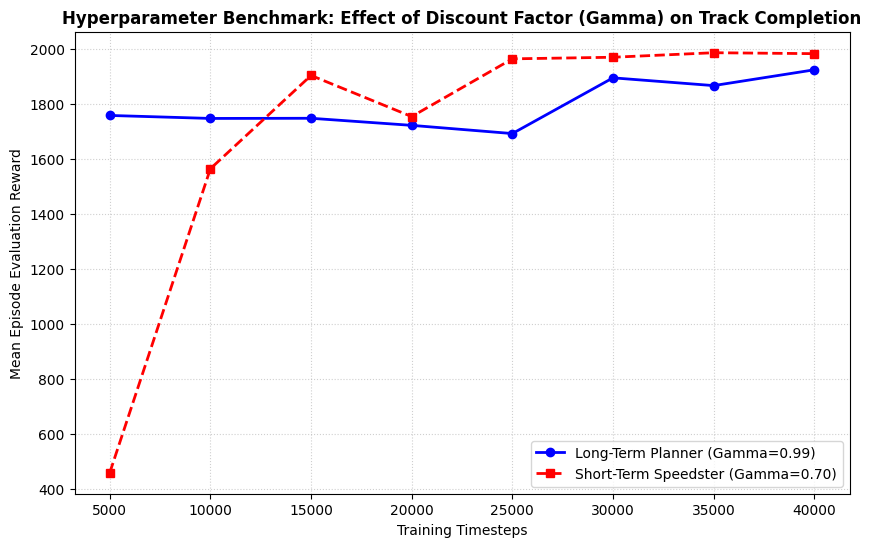

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot both datasets
plt.plot(steps_axis, rewards_long, marker='o', linestyle='-', color='b', linewidth=2, label='Long-Term Planner (Gamma=0.99)')
plt.plot(steps_axis, rewards_short, marker='s', linestyle='--', color='r', linewidth=2, label='Short-Term Speedster (Gamma=0.70)')

# Add formatting
plt.title('Hyperparameter Benchmark: Effect of Discount Factor (Gamma) on Track Completion', fontsize=12, fontweight='bold')
plt.xlabel('Training Timesteps', fontsize=10)
plt.ylabel('Mean Episode Evaluation Reward', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

# Save and render
plt.savefig('hyperparameter_benchmark.png', dpi=300)
plt.show()

In [6]:
obs, info = bm_env.reset()
print("--- Testing the Final Short-Term Speedster Model ---")

for step in range(60):
    # Predict using the short-term model which yielded the highest mean reward
    action, _states = model_short.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = bm_env.step(action)

    # Extract coordinates directly from the environment to see the vehicle progress
    print(f"Step {step:02d} | Action: {action} | Pos: ({bm_env.x:.1f}, {bm_env.y:.1f}) | Velocity: {obs[5]:.1f} | Step Reward: {reward:.2f}")

    if terminated or truncated:
        print(f"--- Simulation Ended! Reason: {'Reached Finish Line!' if bm_env.y >= 115.0 else 'Crashed'} ---")
        break

--- Testing the Final Short-Term Speedster Model ---
Step 00 | Action: 3 | Pos: (0.0, 0.1) | Velocity: 0.5 | Step Reward: 0.50
Step 01 | Action: 3 | Pos: (0.0, 0.2) | Velocity: 1.0 | Step Reward: 1.00
Step 02 | Action: 3 | Pos: (0.0, 0.3) | Velocity: 1.5 | Step Reward: 1.50
Step 03 | Action: 3 | Pos: (0.0, 0.5) | Velocity: 2.0 | Step Reward: 2.00
Step 04 | Action: 3 | Pos: (0.0, 0.8) | Velocity: 2.5 | Step Reward: 2.50
Step 05 | Action: 3 | Pos: (0.0, 1.1) | Velocity: 3.0 | Step Reward: 3.00
Step 06 | Action: 3 | Pos: (0.0, 1.4) | Velocity: 3.5 | Step Reward: 3.50
Step 07 | Action: 3 | Pos: (0.0, 1.8) | Velocity: 4.0 | Step Reward: 4.00
Step 08 | Action: 3 | Pos: (0.0, 2.3) | Velocity: 4.5 | Step Reward: 4.50
Step 09 | Action: 3 | Pos: (0.0, 2.8) | Velocity: 5.0 | Step Reward: 5.00
Step 10 | Action: 3 | Pos: (0.0, 3.3) | Velocity: 5.5 | Step Reward: 5.50
Step 11 | Action: 3 | Pos: (0.0, 3.9) | Velocity: 6.0 | Step Reward: 6.00
Step 12 | Action: 3 | Pos: (0.0, 4.6) | Velocity: 6.5 | Ste